In [ ]:
# @title Library installation
try:
     import dlroms.fespaces as fe
except:
     !pip install git+https://github.com/NicolaRFranco/dlroms.git
     import dlroms.fespaces as fe

import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive',force_remount=True)

import sys
import os

path = '/content/drive/My Drive/MOR/Assignment 1'

if path not in sys.path:
    sys.path.append(path)

from playground import FOMsolver, mesh, Vh

# Assignment 1- Ensuring safety at a kids’ playground
A 2d portion of flooring material of a kids' playground of dimensions 4.2m x 1m ($\Omega ⊂ [0,4.2]\times[0,1]$) made of polyurethane foam it has variable  mechano-elastic properties depending on the manufacturing process:

*   density $\rho \in [10,50] \: kg/m^2$
*   first lamé coefficient $\lambda \in [0.1,1] \: MPa$
*   shear modulus $\mu \in [0.05,0.5] \: MPa$

To model the deformation of the playground floor under the weight of an ambulance, the company is relying on the following equations of linear elasticity:

\begin{equation}
\left\{
\begin{array}{ll}
-\nabla \cdot \left[ \lambda \nabla \cdot \mathbf{u} + \mu \left( \nabla \mathbf{u} + \nabla \mathbf{u}^\top \right) \right] = \mathbf{f} & \text{in } \Omega \\[0.5em]
\mathbf{u} \equiv \mathbf{0} & \text{on } \Gamma_{\text{bottom}} \\[0.5em]
\lambda (\nabla \cdot \mathbf{u}) \cdot \mathbf{n} + \nu \left( \nabla \mathbf{u} + \nabla \mathbf{u}^\top \right) \cdot \mathbf{n} \equiv [0, -mg/4.2]^\top & \text{on } \Gamma_{\text{top}} \\[0.5em]
\lambda (\nabla \cdot \mathbf{u}) \cdot \mathbf{n} + \nu \left( \nabla \mathbf{u} + \nabla \mathbf{u}^\top \right) \cdot \mathbf{n} \equiv 0 & \text{on } \partial \Omega \setminus (\Gamma_{\text{bottom}} \cup \Gamma_{\text{top}})
\end{array}
\right.
\tag{4}
\end{equation}

Here, $\mathbf{u} : \Omega \rightarrow \mathbb{R}^2$ is the displacement vector field, $m$ is the mass of the ambulance, $g \approx 9.81 \text{m/s}^2$ is the gravitational constant, $\mathbf{f} = [0, -\rho g]^\top$ is the body force, whereas $\Gamma_{\text{bottom}} := [0, 4.2] \times \{0\}$ and $\Gamma_{\text{top}} := [0, 4.2] \times \{1\}$.



# Task 1
Let $\boldsymbol{\mu} := [\rho, \lambda, \mu ,m]$. It is requested to collect 30 different FOM simulations by sampling random values of the model parameters between physical ranges provided for $\rho, \lambda $ and $ \mu$. For the ambulance mass,
instead, $3200\:kg ≤ m ≤ 5400\:kg$.

The data must be split into a training and a test set using a 2:1 ratio.

Then the snapshot matrix must be assembled and the decay of the singular values must be studied.

In [ ]:
# @title Data loading and parameters sampling
import random
np.random.seed(0)

# Split
n_total = 30
n_train = 20
n_test = n_total - n_train

# Creation of a class to store the parameters ranges
param_ranges = {
    'rho': (10, 50),
    'lambda_': (0.1e6, 1e6),
    'mu': (0.05e6, 0.5e6),
    'mass': (3200, 5400)
}

# Parameters for the snapshots computation
params_train = np.column_stack([
    np.random.uniform(*param_ranges['rho'], n_train),
    np.random.uniform(*param_ranges['lambda_'], n_train),
    np.random.uniform(*param_ranges['mu'], n_train),
    np.random.uniform(*param_ranges['mass'], n_train)
])

# Parameters for ROM evaluation
params_test = np.column_stack([
    np.random.uniform(*param_ranges['rho'], n_test),
    np.random.uniform(*param_ranges['lambda_'], n_test),
    np.random.uniform(*param_ranges['mu'], n_test),
    np.random.uniform(*param_ranges['mass'], n_test)
])

# Save/load parameters
np.save(os.path.join(path, 'params_train.npy'), params_train)
np.save(os.path.join(path, 'params_test.npy'), params_test)

## Snapshots generation
Using the provided code, the snapshots are generated from the FOM, using the random vaues of the parameters previusly sampled.

Then, the obtained snaphots are divided in training set and test set.

In [ ]:
def generate_snapshots(params, filename):
    snapshots = []
    for rho, lambda_, mu, mass in enumerate(params):
        u = FOMsolver(rho, lambda_, mu, mass)
        snapshots.append(u)
    snapshots = np.column_stack(snapshots)
    np.save(filename, snapshots)
    return snapshots

# Uncomment to generate snashots from FOM
#train_snapshots = generate_snapshots(params_train, os.path.join(path, 'train_snapshots.npy'))
#test_snapshots = generate_snapshots(params_test, os.path.join(path, 'test_snapshots.npy'))

train_snapshots = np.load(os.path.join(path, 'train_snapshots.npy'))
test_snapshots = np.load(os.path.join(path, 'test_snapshots.npy'))

## SVD and singular values decay
In order to obtain the reduced basis, a Singular Value Decomposition is performed on the training snaphots matrix.

Then, by looking at the decay of the singular values, it is possible to choose the number of basis to consider (i.e. the dimension of the reduced space).

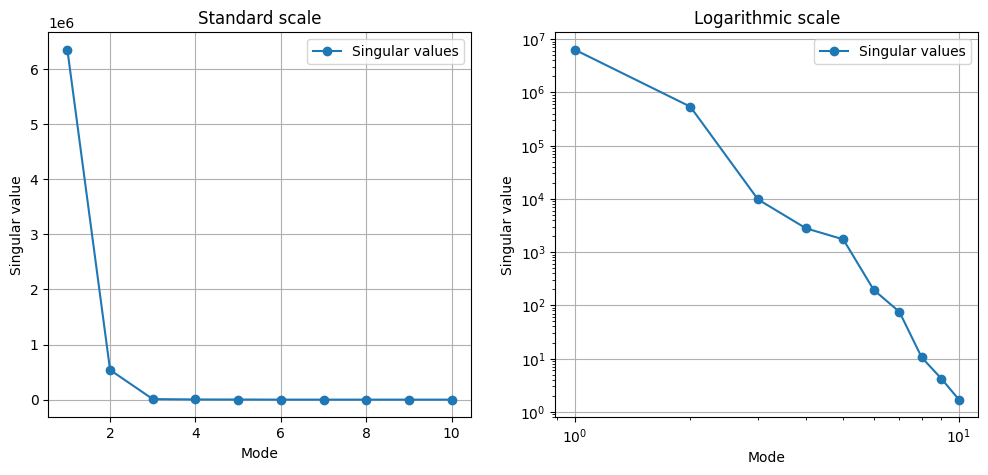

In [ ]:
# @title Singular values decay
from scipy.linalg import svd

U, s, VT = svd(train_snapshots, full_matrices=False)

energy = np.cumsum(s[0:]**2) / np.sum(s[0:]**2)
r = np.argmax(energy > 0.9999) + 1  # 99.999% energy
#print('r =',r)
#print('energy =',(s[0:r]**2).sum()/(s[0:]**2).sum())

# Plot singular values
plt.figure(figsize = (12, 5))

plt.subplot(1,2,1)
plt.plot(np.arange(1,11),s[:10], 'o-', label='Singular values')
#plt.axvline(r+1, color='r', linestyle='--', label=f'r={r}')
plt.xlabel('Mode')
plt.ylabel('Singular value')
plt.legend()
plt.title("Standard scale")
plt.grid()
plt.subplot(1,2,2)
plt.loglog(np.arange(1,11),s[:10], 'o-', label='Singular values')
#plt.axvline(r+1, color='r', linestyle='--', label=f'Truncation r={r}')
plt.xlabel('Mode')
plt.ylabel('Singular value')
plt.legend()
plt.title('Logarithmic scale')
plt.grid()

# plt.subplot(2,2,3)
# plt.plot(np.arange(1,11),s[:10], 'o-', label='Singular values')
# #plt.axvline(r+1, color='r', linestyle='--', label=f'r={r}')
# plt.xlabel('Mode')
# plt.ylabel('Singular value')
# plt.legend()
# plt.title("Standard scale")
# plt.subplot(2,2,4)
# plt.semilogy(np.arange(1,11),s[:10], 'o-', label='Singular values')
# #plt.axvline(r+1, color='r', linestyle='--', label=f'Truncation r={r}')
# plt.xlabel('Mode')
# plt.ylabel('Singular value')
# plt.legend()
# plt.title('Logarithmic scale')
# plt.show()



It's possible to observe that, in the case of interest, the decay of singular values is very fast. This implies that a limited number of modes will, potentially, suffice to represent the solution set.

The number of singular values to consider is then chosen imposing that the energy retained by the consider singular values is higher than 99.99%:

\begin{equation}
Energy = \frac{\sum_{i=1}^{N} \sigma_i^2 }{\sum_{i=1}^{r} \sigma_i^2 } \geq 99.99\%
\end{equation}

Where $r$ represents the rank of the snapshots matrix used to perform the SVD.

In [ ]:
# @title Energy computation
# Evaluation of total energy fraction considering also the first s.v.
energy = (s[0:r]**2).sum()/(s[0:]**2).sum()
print(f'n = {r}, energy = {energy:.6f}')

#r = 4
# Reduced basis
V = U[:, :r]

n = 2, energy = 0.999997


Thus the reduced basis matrix $\mathbb{V}$ is computed by taking the first two columns of $\mathbb{U}$, where $\mathbb{U}$ is the matrix of the left singular vectors obtained through SVD of the snapshots matrix.

It is then possible to plot those two columns (vectors composing the reduced basis):

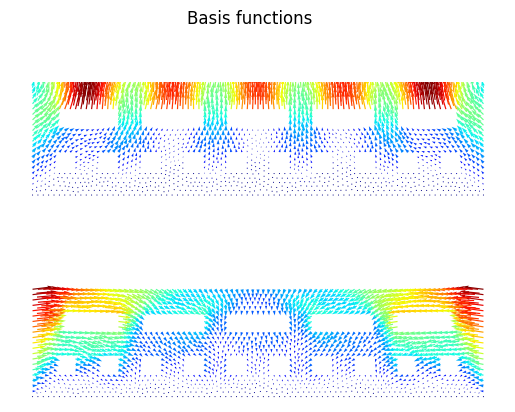

In [ ]:
# @title Basis functions plot
plt.figure()
for j in range(r):
  plt.subplot(max(2,r//2),r-r//2,j+1)
  fe.plot(U[:,j], Vh)
plt.suptitle('Basis functions')
plt.show()

Considering the strong symmetry of the problem, it makes sense that just two basis functions are enough for describing the behaviour of the system.

The first one is capable of differentiating the vertical motion while the second one the horizontal one.

The average projection error can now be computed as </br></br>$$E_{\text{proj}}=\frac{1}{N_{\text{test}}}\sum_{i=1}^{N_\text{test}}\frac{|\mathbf{u}_{i}^{\text{test}}-\mathbf{V}\mathbf{V}^{\top}\mathbf{u}_{i}^{\text{test}}|}{|\mathbf{u}_{i}^{\text{test}}|}$$</br>

In [ ]:
# @title Projection error

from dlroms import num2p
Uproj = V @ (V.T @ test_snapshots)
errors = np.linalg.norm(test_snapshots - Uproj, axis = 0) / np.linalg.norm(test_snapshots, axis = 0)
print("Average projection error: %s." % num2p(errors.mean()))

Average projection error: 0.26%.


# Task 2
It is then requested to implement the reduced basis method through the POD-Galerkin scheme.
All relevant operators are computed offline, so to make the assembling stage as efficient as possible.
Then it is asked to assess the performances of the RB solver in terms of efficiency (computational time) and accuracy (average relative error).

## ROM implementation
Assembling  $\mathbf{A}_N$ and $\mathbf{f}_N$ still involves computations whose complexity depends on the nature of the problem. In this simple case, a key assumption holds: the affine parametric dependence.

$\mathbf{A}_h=\sum_{q=1}^{\theta_a}\mu_{q}\mathbf{A}_{h}^q$    
 $\mathbf{f}_h=\sum_{q=1}^{\theta_f}\mu_{q}\mathbf{f}_{h}^q$

for some fixed $\mathbf{A}_{h}^q$ and $\mathbf{f}_{h}^q$.


Thus, it is possible to pre-compute:

- $\mathbf{f}_N^q:=\mathbf{V}^{\top}\mathbf{f_h}^q$ for $q=1,2$ (as $\mathbf{f}_{h}$ depends on both $\rho$ and $m$);

- $\mathbf{A}_N^{q}:=\mathbf{V}^{\top}\mathbf{A}_{h}^q\mathbf{V}$ for $q=1,2$(as $\mathbf{A}_{h}$ depends on both $\lambda$ and $\mu$).

Then, during the "online phase", given a new parameter instance $\boldsymbol{\mu}$, assembling the ROM boils down to computing:
</br>
- $\mathbf{A}_N=\sum_{q=1}^{2}\mu_{q}\mathbf{A}_N^{q}.$;

- $\mathbf{f}_N=\sum_{q=1}^{2}\mu_{q}\mathbf{f}_N^q$


The matrices $\mathbf{A}_{h}^{1}$, $\mathbf{A}_{h}^{2}$ and the vectors $\mathbf{f}_{h}^{1}$, $\mathbf{f}_{h}^{2}$ are computed in an external file called "ROM_assembler" and in the following cell the matrices $\mathbf{A}_N^{1}$, $\mathbf{A}_N^{2}$ and the vectors $\mathbf{f}_N^1$, $\mathbf{f}_N^2$ are computed.
This procedure is performed offline so that the ROM works faster.

Finally, the ROM is assembled, in particular:
- $$\mathbf{A}_{\boldsymbol{N}} = \lambda \mathbf{A}_N^1 + \mu \mathbf{A}_N^2$$
- $$\mathbf{f}_{\boldsymbol{N}} = \rho \mathbf{f}_N^1 + m \mathbf{f}_N^2$$

Then the RB solver has been defined so that, given a new parameter instance $\lambda,\mu$, $\rho$, m it returns $\tilde{\mathbf{u}}_h = \mathbf{V} \mathbf{u}_N$.


In [ ]:
# @title ROM implementation
from ROM_assembler import Alambda, Amu, Frho, Fmass

# Matrices projection
Arbj = [ V.T @ (A @ V) for A in [ Alambda, Amu]]
frbj = [ V.T @ F for F in [Frho, Fmass]]

# Build matrices in the reduced space (build ROM)
def assembleROM(rho, lambda_, mu, mass):
    Arb = lambda_*Arbj[0] + mu*Arbj[1]
    frb = rho*frbj[0] + mass*frbj[1]
    return Arb, frb

# Solve the ROM
def ROMsolver(rho, lambda_, mu, mass):
    Arb, frb = assembleROM(rho, lambda_, mu, mass)
    c = np.linalg.solve(Arb, frb)
    urb = V @ c
    return urb


Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_dbaae90faca04a47846fa7c1d9fc64596f14f2d8

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    0
  Coefficients:              '[]'
  Unique elements:           'Vector<2 x CG1(?,?)>'
  Unique sub elements:       'Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 0
INFO:FFC:  quadrature_degree: 0
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0555854 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:---------------------------------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_c8200760ff7ba9a9e86a2b7f8555ff38fb61d8ec

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00421834 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0115793 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representati

Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_84462d257af47871692cff30f5a9bdfd10e6d63a

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    1
  Coefficients:              '[f_13]'
  Unique elements:           'Vector<2 x CG1(?,?)>'
  Unique sub elements:       'Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 2
INFO:FFC:  quadrature_degree: 2
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0199463 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:----------------------------------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_53301127d6b914ce791f676319c9fc61a3056dbd

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:                 2
  Number of exterior_facet subdomains: 0
  Rank:                                1
  Arguments:                           '(v_0)'
  Number of coefficients:              1
  Coefficients:                        '[f_16]'
  Unique elements:                     'Vector<2 x CG1(?,?)>'
  Unique sub elements:                 'Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 2
INFO:FFC:  quadrature_degree: 2
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0150592 seconds.

INFO:FFC:Compiler stage 2: Computi

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 49842 stored elements and shape (3840, 3840)>
  Coords	Values
  (0, 0)	0.41506350946108933
  (0, 1)	0.2679491924310787
  (0, 2)	0.13397459621554791
  (0, 3)	-0.133974596215569
  (0, 4)	-0.18301270189220464
  (0, 5)	-0.5
  (0, 6)	-0.36602540378443255
  (0, 7)	0.36602540378449033
  (1, 0)	0.2679491924310787
  (1, 1)	0.41506350946110965
  (1, 2)	0.366025403784431
  (1, 3)	-0.3660254037844887
  (1, 4)	-0.5
  (1, 5)	-0.1830127018921518
  (1, 6)	-0.13397459621550967
  (1, 7)	0.13397459621553087
  (2, 0)	0.13397459621554791
  (2, 1)	0.366025403784431
  (2, 2)	1.01949758092197
  (2, 3)	-0.18860485152306464
  (2, 4)	-0.8382132890102689
  (2, 5)	0.5419985805419602
  (2, 8)	0.15048484201407053
  (2, 9)	-0.2411572029099421
  (2, 10)	-0.46574373014131953
  :	:
  (3837, 3827)	-0.18301270189223262
  (3837, 3836)	0.26794919243116694
  (3837, 3837)	0.4150635094611066
  (3837, 3838)	0.3660254037843843
  (3837, 3839)	-0.3660254037844488
  (383

# Performance assessment


ROM Time: 0.0006s, 
FOM Time: 2.2377s 
Time ratio: ROM time = 0.03% FOM time 
Relative Error: 0.05%


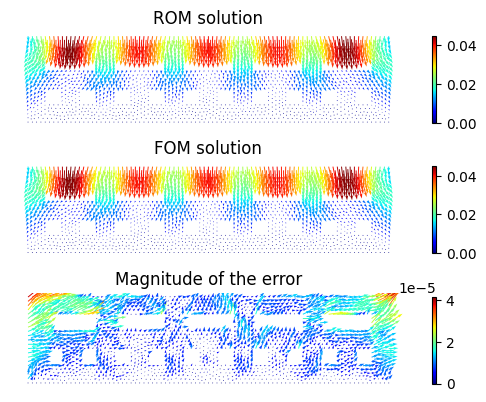

In [ ]:
# @title Relative error and time comparison
# Test on first test parameter
import time

rho_test, lambda_test, mu_test, mass_test = params_test[0]
mu_test = mu_test
# ROM
start = time.time()
uROM = ROMsolver(rho_test, lambda_test, mu_test, mass_test)
rom_time = time.time() - start

# FOM
start = time.time()
uFOM = FOMsolver(rho_test, lambda_test, mu_test, mass_test)
fom_time = time.time() - start

# PLOT
plt.subplot(3,1,1)
fe.plot(uROM, Vh, colorbar=True)
plt.title('ROM solution')
plt.subplot(3,1,2)
fe.plot(uFOM, Vh, colorbar=True)
plt.title('FOM solution')
plt.subplot(3,1,3)
fe.plot(abs(uROM-uFOM), Vh, colorbar=True)
plt.title('Magnitude of the error')

# ERROR
error = np.linalg.norm(uROM - uFOM) / np.linalg.norm(uFOM)
print(f"ROM Time: {rom_time:.4f}s, \nFOM Time: {fom_time:.4f}s \nTime ratio: ROM time = {num2p(rom_time/fom_time)} FOM time \nRelative Error: {num2p(error)}")

# Task 3
 It is requested to fix $\rho = 50\: kg/m^3$, $\lambda = 0.5\:MPa$ and $m = 4500\:kg$.

 For each $\mu$ in the physical range, let $\mathbf{u}_\mu$ denote the corresponding solution to the elasticity equations. Leveraging the ROM, it is requested to draw a plot of the map:
 $$
\mu\to \max_{\mathbf{x}\in\Omega}\vert\vert\mathbf{u}_\mu(\mathbf{x})\vert\vert
 $$
Then, considering that lower values of $\mu$ lead to softer materials, it is asked to find for which $\mu$ value the maximum deformation doesn't exceed $20 \: cm$.

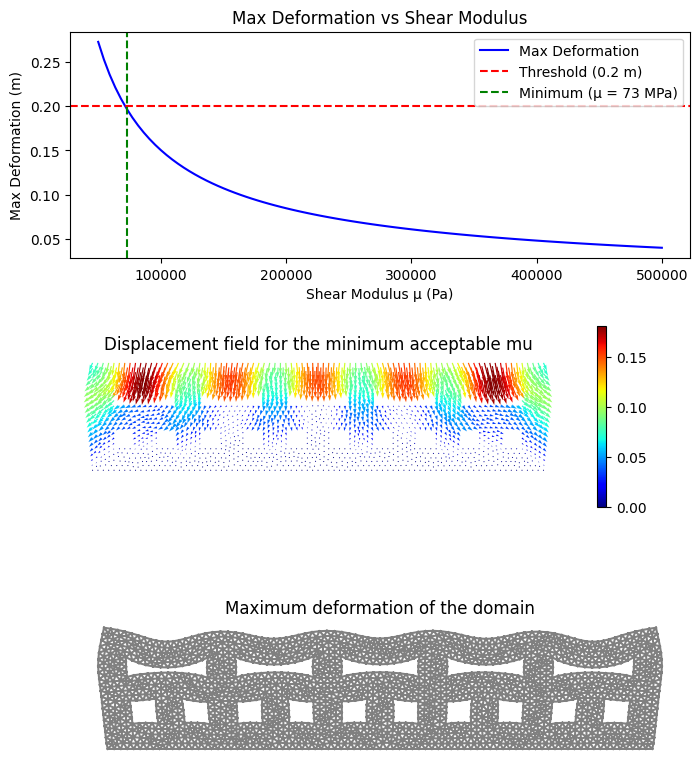

In [ ]:
# @title Study on maximum deformation
# function which computes the maximum deformation for each mu value
def max_deformation(mu_values):
    max_defs = []
    for mu in mu_values:
        u_rom = ROMsolver(50, 0.5e6, mu, 4500)
        u_x = u_rom[:len(u_rom)//2]
        u_y = u_rom[len(u_rom)//2:]
        norms = np.sqrt(u_x**2 + u_y**2)
        max_defs.append(np.max(norms))
    return np.array(max_defs)

mu_values = np.linspace(0.05e6, 0.5e6, 100)
max_defs = max_deformation(mu_values)

# Find smallest mu where deformation <= 0.2 m
mu_threshold = mu_values[np.where(max_defs <= 0.2)[0][0]]

# Plot
plt.figure(figsize=(8, 10))
plt.subplot(3,1,1)
plt.plot(mu_values, max_defs, 'b-', label='Max Deformation')
plt.axhline(0.2, color='r', linestyle='--', label='Threshold (0.2 m)')
plt.axvline(mu_threshold, color='g', linestyle='--', label=f'Minimum (μ = {mu_threshold/1e3:.0f} MPa)')
plt.xlabel('Shear Modulus μ (Pa)')
plt.ylabel('Max Deformation (m)')
plt.legend()
plt.title('Max Deformation vs Shear Modulus')

uROM = ROMsolver(50, 0.5e6, mu_threshold, 4500)

plt.subplot(3,1,2)
fe.plot(uROM, Vh, colorbar=True)
plt.title('Displacement field for the minimum acceptable mu')

plt.subplot(3,1,3)
fe.plot(uROM, Vh, warp = True)
plt.title('Maximum deformation of the domain')
plt.show()